# HW1: Finite-Horizon Asset Allocation with CARA Utility

This notebook formulates the assignment as a finite-horizon MDP, solves a discretized version using sampled backward induction, and validates the learned policy with Monte Carlo simulation and buy-and-hold comparison.

**Recommended workflow**
1. Run all cells once.
2. Start with the default main case `(n=3, T=5)`.
3. Then run the four-case experiment block at the end.

**Important**: the largest case `(n=4, T=8)` can still be slow. This notebook uses a lighter discretization for that case automatically.

## Part 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
import time


## Part 2. Main-case parameters

These are the default parameters for a single demonstration run. The four-case experiment runner later will override them automatically per case.

In [2]:
# ===== Main demonstration case =====
T = 5
n_risky = 3

r = 0.02
alpha = 1.0

means = np.array([0.06, 0.08, 0.04])
vars_ = np.array([0.04, 0.09, 0.02])
stds = np.sqrt(vars_)

initial_wealth = 1.0
initial_portfolio = np.array([0.4, 0.2, 0.2, 0.2])  # [cash, asset1, asset2, asset3]

max_turnover = 0.10

# discretization
weight_step = 0.1
wealth_min = 0.5
wealth_max = 2.0
wealth_bins = 8

# numerical
n_mc = 10
n_sims = 200


## Part 3. Utility and helper functions

In [3]:
def cara_utility(w, alpha):
    return -np.exp(-alpha * w)

def turnover(p, q):
    return 0.5 * np.sum(np.abs(np.array(p) - np.array(q)))

def generate_weight_grid(n_assets, step):
    points = np.arange(0, 1 + 1e-9, step)
    grid = []
    for combo in product(points, repeat=n_assets):
        if abs(sum(combo) - 1.0) < 1e-9:
            grid.append(np.array(combo))
    return grid

def feasible_actions(current_p, weight_grid, max_turnover):
    return [q for q in weight_grid if turnover(current_p, q) <= max_turnover + 1e-12]

def wealth_to_bin(w, w_min, w_max, n_bins):
    if w <= w_min:
        return 0
    if w >= w_max:
        return n_bins - 1
    ratio = (w - w_min) / (w_max - w_min)
    return min(n_bins - 1, int(ratio * n_bins))

def nearest_weight_index(p, weight_grid):
    distances = [np.sum(np.abs(p - wg)) for wg in weight_grid]
    return int(np.argmin(distances))

def representative_wealth_from_bin(wb, wealth_min, wealth_max, wealth_bins):
    return wealth_min + (wealth_max - wealth_min) * wb / (wealth_bins - 1)


## Part 4. Transition dynamics

In [4]:
def sample_risky_returns(means, stds, rng):
    return rng.normal(means, stds)

def transition(wealth, target_weights, r, means, stds, rng):
    risky_returns = sample_risky_returns(means, stds, rng)
    gross_returns = np.concatenate(([1 + r], 1 + risky_returns))
    next_asset_values = wealth * np.array(target_weights) * gross_returns
    next_wealth = np.sum(next_asset_values)
    next_weights = next_asset_values / next_wealth
    return next_wealth, next_weights


## Part 5. Build the default weight grid

In [5]:
weight_grid = generate_weight_grid(n_risky + 1, weight_step)
print("Number of weight grid points:", len(weight_grid))
print("Number of states:", wealth_bins * len(weight_grid))


Number of weight grid points: 286
Number of states: 2288


## Part 6. Quick one-step transition check

In [6]:
test_q = weight_grid[0]
rng_test = np.random.default_rng(42)
next_w, next_p = transition(initial_wealth, test_q, r, means, stds, rng_test)
print("Chosen target weights:", test_q)
print("Next wealth:", next_w)
print("Next weights:", next_p)
print("Sum of next weights:", next_p.sum())


Chosen target weights: [0. 0. 0. 1.]
Next wealth: 1.1461298259008599
Next weights: [0. 0. 0. 1.]
Sum of next weights: 1.0


## Part 7. Solver: sampled finite-horizon dynamic programming

In [7]:
def solve_finite_horizon_dp(
    T, weight_grid, wealth_min, wealth_max, wealth_bins,
    r, alpha, means, stds, max_turnover, n_mc, rng,
    progress_every=200
):
    start_total = time.time()
    V = [dict() for _ in range(T + 1)]
    policy = [dict() for _ in range(T)]
    n_weight_states = len(weight_grid)
    total_states_per_period = wealth_bins * n_weight_states
    print("=" * 60)
    print("Starting finite-horizon DP")
    print(f"T = {T}")
    print(f"wealth_bins = {wealth_bins}")
    print(f"number of weight states = {n_weight_states}")
    print(f"states per period = {total_states_per_period}")
    print(f"Monte Carlo samples per action = {n_mc}")
    print("=" * 60)
    terminal_start = time.time()
    for wb in range(wealth_bins):
        wealth_rep = representative_wealth_from_bin(wb, wealth_min, wealth_max, wealth_bins)
        for wi, p in enumerate(weight_grid):
            state = (wb, wi)
            V[T][state] = cara_utility(wealth_rep, alpha)
    terminal_end = time.time()
    print(f"Terminal values initialized in {terminal_end - terminal_start:.2f} seconds")
    feasible_action_map = {}
    action_count_list = []
    precompute_start = time.time()
    for wi, p in enumerate(weight_grid):
        actions = feasible_actions(p, weight_grid, max_turnover)
        feasible_action_map[wi] = actions
        action_count_list.append(len(actions))
    precompute_end = time.time()
    print(f"Feasible actions precomputed in {precompute_end - precompute_start:.2f} seconds")
    print(f"Min feasible actions: {min(action_count_list)}")
    print(f"Max feasible actions: {max(action_count_list)}")
    print(f"Average feasible actions: {np.mean(action_count_list):.2f}")
    print("=" * 60)
    for t in range(T - 1, -1, -1):
        period_start = time.time()
        print(f"\nSolving period t = {t}")
        state_counter = 0
        for wb in range(wealth_bins):
            bin_start = time.time()
            wealth_rep = representative_wealth_from_bin(wb, wealth_min, wealth_max, wealth_bins)
            print(f"  Wealth bin {wb+1}/{wealth_bins} (representative wealth = {wealth_rep:.4f})")
            for wi, p in enumerate(weight_grid):
                state = (wb, wi)
                actions = feasible_action_map[wi]
                best_value = -np.inf
                best_action = None
                for q in actions:
                    continuation_values = []
                    for _ in range(n_mc):
                        next_w, next_p = transition(wealth_rep, q, r, means, stds, rng)
                        next_wb = wealth_to_bin(next_w, wealth_min, wealth_max, wealth_bins)
                        next_wi = nearest_weight_index(next_p, weight_grid)
                        next_state = (next_wb, next_wi)
                        continuation_values.append(V[t + 1][next_state])
                    action_value = np.mean(continuation_values)
                    if action_value > best_value:
                        best_value = action_value
                        best_action = q
                V[t][state] = best_value
                policy[t][state] = best_action
                state_counter += 1
                if progress_every and state_counter % progress_every == 0:
                    elapsed = time.time() - period_start
                    pct = 100 * state_counter / total_states_per_period
                    print(f"    Progress: {state_counter}/{total_states_per_period} states ({pct:.1f}%), elapsed {elapsed:.1f}s")
            bin_end = time.time()
            print(f"    Finished wealth bin {wb+1}/{wealth_bins} in {bin_end - bin_start:.2f} seconds")
        period_end = time.time()
        print(f"Completed period t = {t} in {period_end - period_start:.2f} seconds")
    end_total = time.time()
    print("\n" + "=" * 60)
    print(f"All DP finished in {end_total - start_total:.2f} seconds")
    print("=" * 60)
    return V, policy


## Part 8. Solve the default main case

In [8]:
part8_start = time.time()
V, policy = solve_finite_horizon_dp(
    T=T,
    weight_grid=weight_grid,
    wealth_min=wealth_min,
    wealth_max=wealth_max,
    wealth_bins=wealth_bins,
    r=r,
    alpha=alpha,
    means=means,
    stds=stds,
    max_turnover=max_turnover,
    n_mc=n_mc,
    rng=np.random.default_rng(42),
    progress_every=200
)
part8_end = time.time()
print(f"\nPart 8 runtime: {part8_end - part8_start:.2f} seconds")
initial_wb = wealth_to_bin(initial_wealth, wealth_min, wealth_max, wealth_bins)
initial_wi = nearest_weight_index(initial_portfolio, weight_grid)
initial_state = (initial_wb, initial_wi)
print("Initial state:", initial_state)
print("Optimal action at t=0:", policy[0][initial_state])
actions0 = feasible_actions(initial_portfolio, weight_grid, max_turnover)
print("Number of feasible actions:", len(actions0))
for a in actions0:
    print(a, "turnover =", turnover(initial_portfolio, a))


Starting finite-horizon DP
T = 5
wealth_bins = 8
number of weight states = 286
states per period = 2288
Monte Carlo samples per action = 10
Terminal values initialized in 0.02 seconds
Feasible actions precomputed in 1.66 seconds
Min feasible actions: 4
Max feasible actions: 13
Average feasible actions: 10.23

Solving period t = 4
  Wealth bin 1/8 (representative wealth = 0.5000)
    Progress: 200/2288 states (8.7%), elapsed 100.0s
    Finished wealth bin 1/8 in 140.68 seconds
  Wealth bin 2/8 (representative wealth = 0.7143)
    Progress: 400/2288 states (17.5%), elapsed 193.4s
    Finished wealth bin 2/8 in 138.11 seconds
  Wealth bin 3/8 (representative wealth = 0.9286)
    Progress: 600/2288 states (26.2%), elapsed 290.3s
    Progress: 800/2288 states (35.0%), elapsed 391.5s
    Finished wealth bin 3/8 in 138.96 seconds
  Wealth bin 4/8 (representative wealth = 1.1429)
    Progress: 1000/2288 states (43.7%), elapsed 484.4s
    Finished wealth bin 4/8 in 138.11 seconds
  Wealth bin 5

## Part 9. Policy validation: single path, many simulations, and baseline comparison

In [9]:
def simulate_policy(
    policy, T, initial_wealth, initial_portfolio, weight_grid,
    wealth_min, wealth_max, wealth_bins,
    r, means, stds, rng, alpha
):
    wealth = initial_wealth
    p = initial_portfolio.copy()
    wealth_path = [wealth]
    portfolio_path = [p.copy()]
    action_path = []
    state_path = []
    for t in range(T):
        wb = wealth_to_bin(wealth, wealth_min, wealth_max, wealth_bins)
        wi = nearest_weight_index(p, weight_grid)
        state = (wb, wi)
        state_path.append(state)
        q = policy[t][state]
        action_path.append(q.copy())
        wealth, p = transition(wealth, q, r, means, stds, rng)
        wealth_path.append(wealth)
        portfolio_path.append(p.copy())
    terminal_wealth = wealth
    terminal_utility = cara_utility(terminal_wealth, alpha)
    return {
        "wealth_path": wealth_path,
        "portfolio_path": portfolio_path,
        "action_path": action_path,
        "state_path": state_path,
        "terminal_wealth": terminal_wealth,
        "terminal_utility": terminal_utility
    }

def run_many_simulations(
    n_sims, policy, T, initial_wealth, initial_portfolio, weight_grid,
    wealth_min, wealth_max, wealth_bins,
    r, means, stds, alpha, seed=123
):
    rng = np.random.default_rng(seed)
    terminal_wealths = []
    terminal_utilities = []
    wealth_paths = []
    for _ in range(n_sims):
        result = simulate_policy(
            policy=policy,
            T=T,
            initial_wealth=initial_wealth,
            initial_portfolio=initial_portfolio,
            weight_grid=weight_grid,
            wealth_min=wealth_min,
            wealth_max=wealth_max,
            wealth_bins=wealth_bins,
            r=r,
            means=means,
            stds=stds,
            rng=rng,
            alpha=alpha
        )
        terminal_wealths.append(result["terminal_wealth"])
        terminal_utilities.append(result["terminal_utility"])
        wealth_paths.append(result["wealth_path"])
    return {
        "terminal_wealths": np.array(terminal_wealths),
        "terminal_utilities": np.array(terminal_utilities),
        "wealth_paths": wealth_paths
    }

def simulate_buy_and_hold(T, initial_wealth, initial_portfolio, r, means, stds, rng, alpha):
    wealth = initial_wealth
    p = initial_portfolio.copy()
    wealth_path = [wealth]
    portfolio_path = [p.copy()]
    for _ in range(T):
        risky_returns = rng.normal(means, stds)
        gross_returns = np.concatenate(([1 + r], 1 + risky_returns))
        next_asset_values = wealth * p * gross_returns
        wealth = np.sum(next_asset_values)
        p = next_asset_values / wealth
        wealth_path.append(wealth)
        portfolio_path.append(p.copy())
    terminal_wealth = wealth
    terminal_utility = cara_utility(terminal_wealth, alpha)
    return {
        "wealth_path": wealth_path,
        "portfolio_path": portfolio_path,
        "terminal_wealth": terminal_wealth,
        "terminal_utility": terminal_utility
    }

def run_many_buy_and_hold(n_sims, T, initial_wealth, initial_portfolio, r, means, stds, alpha, seed=123):
    rng = np.random.default_rng(seed)
    terminal_wealths = []
    terminal_utilities = []
    wealth_paths = []
    for _ in range(n_sims):
        result = simulate_buy_and_hold(T, initial_wealth, initial_portfolio, r, means, stds, rng, alpha)
        terminal_wealths.append(result["terminal_wealth"])
        terminal_utilities.append(result["terminal_utility"])
        wealth_paths.append(result["wealth_path"])
    return {
        "terminal_wealths": np.array(terminal_wealths),
        "terminal_utilities": np.array(terminal_utilities),
        "wealth_paths": wealth_paths
    }


### Part 9.1 Single-path check

In [10]:
single_sim = simulate_policy(
    policy=policy,
    T=T,
    initial_wealth=initial_wealth,
    initial_portfolio=initial_portfolio,
    weight_grid=weight_grid,
    wealth_min=wealth_min,
    wealth_max=wealth_max,
    wealth_bins=wealth_bins,
    r=r,
    means=means,
    stds=stds,
    rng=np.random.default_rng(123),
    alpha=alpha
)
print("Single-path wealth path:")
print(single_sim["wealth_path"])
print("\nSingle-path action path:")
for t, a in enumerate(single_sim["action_path"]):
    print(f"t={t}, action={a}")
print("\nTerminal wealth:", single_sim["terminal_wealth"])
print("Terminal utility:", single_sim["terminal_utility"])


Single-path wealth path:
[1.0, 1.01376237479074, 1.172824446702954, 1.2409779147791988, 1.2868369250135507, 1.4013335203840422]

Single-path action path:
t=0, action=[0.3 0.2 0.3 0.2]
t=1, action=[0.3 0.2 0.3 0.2]
t=2, action=[0.3 0.3 0.3 0.1]
t=3, action=[0.3 0.4 0.3 0. ]
t=4, action=[0.3 0.4 0.3 0. ]

Terminal wealth: 1.4013335203840422
Terminal utility: -0.24626834102492498


In [11]:
print("Check that portfolio weights sum to 1:")
for t, p in enumerate(single_sim["portfolio_path"]):
    print(f"t={t}, sum={np.sum(p):.8f}, portfolio={p}")


Check that portfolio weights sum to 1:
t=0, sum=1.00000000, portfolio=[0.4 0.2 0.2 0.2]
t=1, sum=1.00000000, portfolio=[0.30184588 0.17009425 0.28695009 0.24110978]
t=2, sum=1.00000000, portfolio=[0.26449934 0.18995459 0.35164649 0.19389959]
t=3, sum=1.00000000, portfolio=[0.28919474 0.26444513 0.35230317 0.09405696]
t=4, sum=1.00000000, portfolio=[0.29509508 0.3840179  0.32088702 0.        ]
t=5, sum=1.00000000, portfolio=[0.28099813 0.47693766 0.24206421 0.        ]


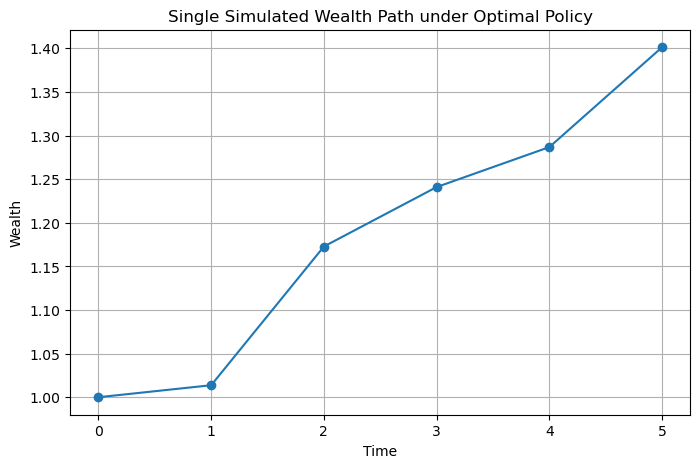

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(T + 1), single_sim["wealth_path"], marker='o')
plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Single Simulated Wealth Path under Optimal Policy")
plt.grid(True)
plt.show()


### Part 9.2 Many simulations under the optimal policy

In [13]:
sim_summary = run_many_simulations(
    n_sims=n_sims,
    policy=policy,
    T=T,
    initial_wealth=initial_wealth,
    initial_portfolio=initial_portfolio,
    weight_grid=weight_grid,
    wealth_min=wealth_min,
    wealth_max=wealth_max,
    wealth_bins=wealth_bins,
    r=r,
    means=means,
    stds=stds,
    alpha=alpha,
    seed=123
)
print(f"Number of simulations: {n_sims}")
print("Average terminal wealth:", np.mean(sim_summary["terminal_wealths"]))
print("Std terminal wealth:", np.std(sim_summary["terminal_wealths"]))
print("Average terminal utility:", np.mean(sim_summary["terminal_utilities"]))
print("Min terminal wealth:", np.min(sim_summary["terminal_wealths"]))
print("Max terminal wealth:", np.max(sim_summary["terminal_wealths"]))


Number of simulations: 200
Average terminal wealth: 1.3010218845380754
Std terminal wealth: 0.35322503575773584
Average terminal utility: -0.2884480209329306
Min terminal wealth: 0.6794778822649344
Max terminal wealth: 2.4602167952706626


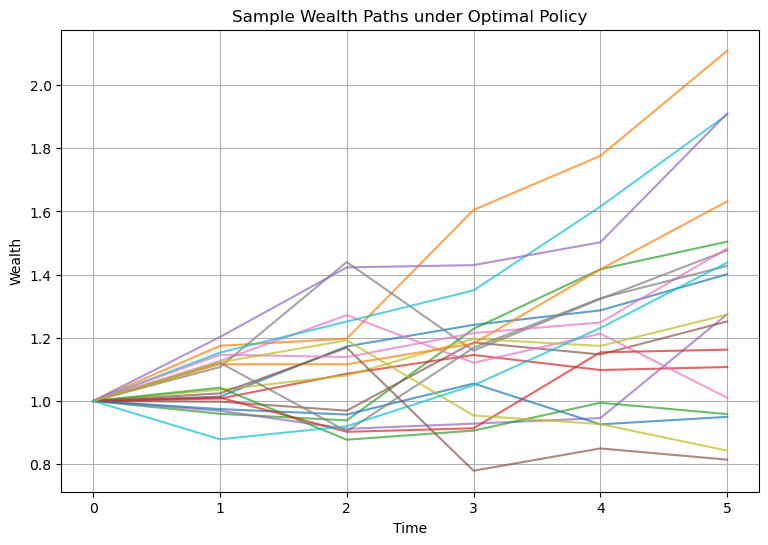

In [14]:
plt.figure(figsize=(9, 6))
for path in sim_summary["wealth_paths"][:20]:
    plt.plot(range(T + 1), path, alpha=0.7)
plt.xlabel("Time")
plt.ylabel("Wealth")
plt.title("Sample Wealth Paths under Optimal Policy")
plt.grid(True)
plt.show()


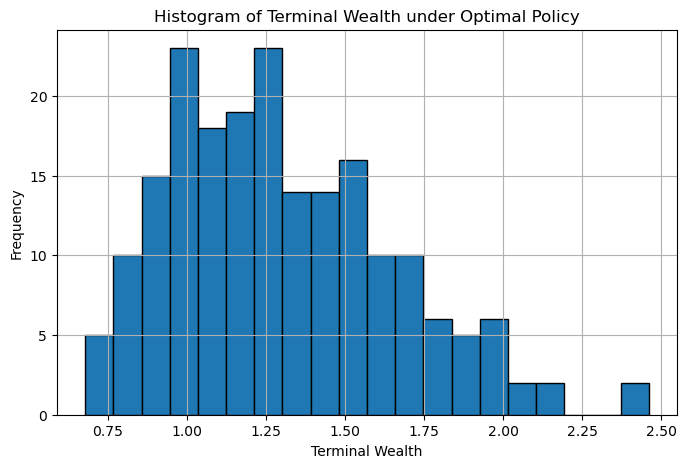

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(sim_summary["terminal_wealths"], bins=20, edgecolor='black')
plt.xlabel("Terminal Wealth")
plt.ylabel("Frequency")
plt.title("Histogram of Terminal Wealth under Optimal Policy")
plt.grid(True)
plt.show()


### Part 9.3 Buy-and-hold baseline comparison

In [16]:
bh_summary = run_many_buy_and_hold(
    n_sims=n_sims,
    T=T,
    initial_wealth=initial_wealth,
    initial_portfolio=initial_portfolio,
    r=r,
    means=means,
    stds=stds,
    alpha=alpha,
    seed=123
)
comparison_df = pd.DataFrame({
    "Metric": [
        "Average terminal wealth",
        "Std terminal wealth",
        "Average terminal utility",
        "Min terminal wealth",
        "Max terminal wealth"
    ],
    "Optimal Policy": [
        np.mean(sim_summary["terminal_wealths"]),
        np.std(sim_summary["terminal_wealths"]),
        np.mean(sim_summary["terminal_utilities"]),
        np.min(sim_summary["terminal_wealths"]),
        np.max(sim_summary["terminal_wealths"])
    ],
    "Buy-and-Hold": [
        np.mean(bh_summary["terminal_wealths"]),
        np.std(bh_summary["terminal_wealths"]),
        np.mean(bh_summary["terminal_utilities"]),
        np.min(bh_summary["terminal_wealths"]),
        np.max(bh_summary["terminal_wealths"])
    ]
})
comparison_df


,Metric,Optimal Policy,Buy-and-Hold
0,Average terminal wealth,1.301022,1.239923
1,Std terminal wealth,0.353225,0.237196
2,Average terminal utility,-0.288448,-0.297250
3,Min terminal wealth,0.679478,0.817076
4,Max terminal wealth,2.460217,1.938577


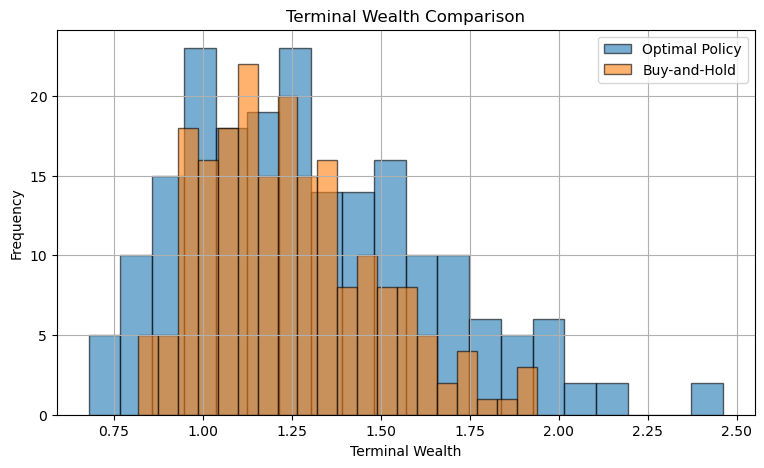

In [17]:
plt.figure(figsize=(9, 5))
plt.hist(sim_summary["terminal_wealths"], bins=20, alpha=0.6, label="Optimal Policy", edgecolor='black')
plt.hist(bh_summary["terminal_wealths"], bins=20, alpha=0.6, label="Buy-and-Hold", edgecolor='black')
plt.xlabel("Terminal Wealth")
plt.ylabel("Frequency")
plt.title("Terminal Wealth Comparison")
plt.legend()
plt.grid(True)
plt.show()


## Part 10. Four-case experiment runner

This block runs the representative cases `(3,5)`, `(3,8)`, `(4,5)`, `(4,8)`. The last case is automatically lightened.

In [18]:
def get_experiment_params(n_risky, T):
    params = {}
    params["T"] = T
    params["n_risky"] = n_risky
    params["r"] = 0.02
    params["alpha"] = 1.0
    if n_risky == 3:
        params["means"] = np.array([0.06, 0.08, 0.04])
        params["vars_"] = np.array([0.04, 0.09, 0.02])
        params["initial_portfolio"] = np.array([0.4, 0.2, 0.2, 0.2])
    elif n_risky == 4:
        params["means"] = np.array([0.06, 0.08, 0.04, 0.07])
        params["vars_"] = np.array([0.04, 0.09, 0.02, 0.05])
        params["initial_portfolio"] = np.array([0.3, 0.175, 0.175, 0.175, 0.175])
    else:
        raise ValueError("Only n_risky = 3 or 4 is supported here.")
    params["stds"] = np.sqrt(params["vars_"])
    params["initial_wealth"] = 1.0
    params["max_turnover"] = 0.10
    params["weight_step"] = 0.1
    params["wealth_min"] = 0.5
    params["wealth_max"] = 2.0
    params["wealth_bins"] = 8
    params["n_mc"] = 10
    params["n_sims"] = 200
    if n_risky == 4 and T == 8:
        params["wealth_bins"] = 6
        params["n_mc"] = 5
        params["n_sims"] = 100
    return params


In [19]:
def run_experiment(n_risky, T, seed=42):
    params = get_experiment_params(n_risky, T)
    T = params["T"]
    r = params["r"]
    alpha = params["alpha"]
    means = params["means"]
    stds = params["stds"]
    initial_wealth = params["initial_wealth"]
    initial_portfolio = params["initial_portfolio"]
    max_turnover = params["max_turnover"]
    weight_step = params["weight_step"]
    wealth_min = params["wealth_min"]
    wealth_max = params["wealth_max"]
    wealth_bins = params["wealth_bins"]
    n_mc = params["n_mc"]
    n_sims = params["n_sims"]
    print("=" * 70)
    print(f"Running experiment: n_risky={n_risky}, T={T}")
    print("=" * 70)
    weight_grid = generate_weight_grid(n_risky + 1, weight_step)
    print("Number of weight grid points:", len(weight_grid))
    print("Number of states:", len(weight_grid) * wealth_bins)
    rng_solver = np.random.default_rng(seed)
    start_time = time.time()
    V, policy = solve_finite_horizon_dp(
        T=T,
        weight_grid=weight_grid,
        wealth_min=wealth_min,
        wealth_max=wealth_max,
        wealth_bins=wealth_bins,
        r=r,
        alpha=alpha,
        means=means,
        stds=stds,
        max_turnover=max_turnover,
        n_mc=n_mc,
        rng=rng_solver,
        progress_every=200
    )
    runtime = time.time() - start_time
    initial_wb = wealth_to_bin(initial_wealth, wealth_min, wealth_max, wealth_bins)
    initial_wi = nearest_weight_index(initial_portfolio, weight_grid)
    initial_state = (initial_wb, initial_wi)
    initial_action = policy[0][initial_state]
    sim_summary = run_many_simulations(
        n_sims=n_sims,
        policy=policy,
        T=T,
        initial_wealth=initial_wealth,
        initial_portfolio=initial_portfolio,
        weight_grid=weight_grid,
        wealth_min=wealth_min,
        wealth_max=wealth_max,
        wealth_bins=wealth_bins,
        r=r,
        means=means,
        stds=stds,
        alpha=alpha,
        seed=123
    )
    bh_summary = run_many_buy_and_hold(
        n_sims=n_sims,
        T=T,
        initial_wealth=initial_wealth,
        initial_portfolio=initial_portfolio,
        r=r,
        means=means,
        stds=stds,
        alpha=alpha,
        seed=123
    )
    result = {
        "n_risky": n_risky,
        "T": T,
        "runtime_sec": runtime,
        "num_weight_grid": len(weight_grid),
        "num_states": len(weight_grid) * wealth_bins,
        "initial_action": np.round(initial_action, 3).tolist(),
        "opt_avg_terminal_wealth": float(np.mean(sim_summary["terminal_wealths"])),
        "opt_std_terminal_wealth": float(np.std(sim_summary["terminal_wealths"])),
        "opt_avg_terminal_utility": float(np.mean(sim_summary["terminal_utilities"])),
        "bh_avg_terminal_wealth": float(np.mean(bh_summary["terminal_wealths"])),
        "bh_std_terminal_wealth": float(np.std(bh_summary["terminal_wealths"])),
        "bh_avg_terminal_utility": float(np.mean(bh_summary["terminal_utilities"])),
    }
    print("\nInitial action:", result["initial_action"])
    print("Optimal policy avg terminal wealth:", result["opt_avg_terminal_wealth"])
    print("Buy-and-hold avg terminal wealth:", result["bh_avg_terminal_wealth"])
    print("Optimal policy avg terminal utility:", result["opt_avg_terminal_utility"])
    print("Buy-and-hold avg terminal utility:", result["bh_avg_terminal_utility"])
    print(f"Runtime: {runtime:.2f} seconds")
    details = {
        "sim_summary": sim_summary,
        "bh_summary": bh_summary,
        "policy": policy,
        "weight_grid": weight_grid,
        "params": params
    }
    return result, details


In [20]:

experiment_list = [
    (3, 5),
    (3, 8),
    (4, 5),
    (4, 8),
]
all_results = []
all_details = {}

# Running all four cases may still take time.
# You can comment out the largest case first if needed.
for n_risky_case, T_case in experiment_list:
    result, details = run_experiment(n_risky_case, T_case)
    all_results.append(result)
    all_details[(n_risky_case, T_case)] = details


Running experiment: n_risky=3, T=5
Number of weight grid points: 286
Number of states: 2288
Starting finite-horizon DP
T = 5
wealth_bins = 8
number of weight states = 286
states per period = 2288
Monte Carlo samples per action = 10
Terminal values initialized in 0.02 seconds
Feasible actions precomputed in 1.63 seconds
Min feasible actions: 4
Max feasible actions: 13
Average feasible actions: 10.23

Solving period t = 4
  Wealth bin 1/8 (representative wealth = 0.5000)
    Progress: 200/2288 states (8.7%), elapsed 98.8s
    Finished wealth bin 1/8 in 139.71 seconds
  Wealth bin 2/8 (representative wealth = 0.7143)
    Progress: 400/2288 states (17.5%), elapsed 192.9s
    Finished wealth bin 2/8 in 139.81 seconds
  Wealth bin 3/8 (representative wealth = 0.9286)
    Progress: 600/2288 states (26.2%), elapsed 290.6s
    Progress: 800/2288 states (35.0%), elapsed 392.6s
    Finished wealth bin 3/8 in 139.42 seconds
  Wealth bin 4/8 (representative wealth = 1.1429)
    Progress: 1000/2288 

KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(all_results)
results_df


## Part 11. Optional: plot one chosen experiment from the batch

In [ ]:
chosen_case = (3, 5)
if chosen_case in all_details:
    chosen_sim = all_details[chosen_case]["sim_summary"]
    chosen_bh = all_details[chosen_case]["bh_summary"]
    plt.figure(figsize=(9, 5))
    plt.hist(chosen_sim["terminal_wealths"], bins=20, alpha=0.6, label="Optimal Policy", edgecolor='black')
    plt.hist(chosen_bh["terminal_wealths"], bins=20, alpha=0.6, label="Buy-and-Hold", edgecolor='black')
    plt.xlabel("Terminal Wealth")
    plt.ylabel("Frequency")
    plt.title(f"Terminal Wealth Comparison for case n={chosen_case[0]}, T={chosen_case[1]}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Chosen case not found in all_details. Run the four-case block first.")


## Part 12. Notes for the report

Use these outputs in your PDF report:
- the MDP formulation from Parts 2–4,
- the initial optimal action from Part 8,
- the single-path validation from Part 9.1,
- the summary statistics and histograms from Part 9.2–9.3,
- the four-case table from Part 10.